In [1]:
import numpy as np, json, os, sys, pandas as pd
import random
sys.path.append("../")
from bound_analysis.new_bound_core import compute_new_error_bound
from bound_analysis.old_bound_core import compute_old_error_bound, compute_updated_old_error_bound
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# load results and pairwise metrics
all_algos = ["simclr", "ijepa", "mae", "clip"]
cur_algo = all_algos[3]
nccc_dir = f"../results/{cur_algo}/nccc"
nccc_df = pd.read_csv(os.path.join(nccc_dir, "results.csv"))

import ast
def get_average_nccc(df):
    df["train_acc"] = df["train_acc"].apply(lambda x: float(ast.literal_eval(x)[0]))
    df["test_acc"]  = df["test_acc"].apply(lambda x: float(ast.literal_eval(x)[0]))
    # Group by n_shot and compute mean ± std across seeds
    summary = df.groupby("n_shot").agg(
        train_mean=("train_acc", "mean"),
        train_std=("train_acc", "std"),
        test_mean=("test_acc", "mean"),
        test_std=("test_acc", "std"),
    ).reset_index().sort_values("n_shot")
    return summary

nccc_df = get_average_nccc(nccc_df)
nccc_df.head()

,n_shot,train_mean,train_std,test_mean,test_std
0,1,0.9884,0.014809,0.988,0.016432
1,5,0.9966,0.002702,0.992,0.013038
2,10,0.9960,0.004301,0.988,0.013038
3,20,0.9972,0.003114,0.992,0.008367
4,50,0.9974,0.002702,0.990,0.010000


### Old bound

In [9]:
geom_dir = f"../results/{cur_algo}/geometry"
cdnv_file = os.path.join(geom_dir, "cdnv.csv")
cdnv_df = pd.read_csv(cdnv_file)
cdnv = cdnv_df["CDNV"].values[0]
print(f"CDNV: {cdnv}")
dir_cdnv = cdnv_df["Directional_CDNV"].values[0]
print(f"Directional CDNV: {dir_cdnv}")

CDNV: 0.9238845705986024
Directional CDNV: 0.019178956747055


In [10]:
from collections import defaultdict
old_train_error_bounds = defaultdict()
old_test_error_bounds = defaultdict()
for m in nccc_df["n_shot"].values:
    err_bound = compute_updated_old_error_bound(dir_cdnv, cdnv, m)
    old_train_error_bounds[int(m)] = float(err_bound)
    err_bound = compute_old_error_bound(dir_cdnv, cdnv, m)
    old_test_error_bounds[int(m)] = float(err_bound)

print("Old Train Error Bounds:", old_train_error_bounds)
print("Old Test Error Bounds:", old_test_error_bounds)

Old Train Error Bounds: defaultdict(None, {1: 16.080042733884028, 5: 4.276446305995087, 10: 2.881933464221244, 20: 2.0651876408250898, 50: 1.4092226326800392, 100: 1.0861367555161578, 200: 0.8523331929912241, 500: 0.6331155421069175})
Old Test Error Bounds: defaultdict(None, {1: 36.859182414648124, 5: 5.538849493003944, 10: 2.9440337540908303, 20: 1.6800665035210247, 50: 0.8646501292187997, 100: 0.5476962051701691, 200: 0.35951647896870603, 500: 0.22014549355255603})


### New bound

In [11]:
geom_dir = f"../results/{cur_algo}/geometry"
train_metrics_file = os.path.join(geom_dir, "train_pairwise_metrics.json")
test_metrics_file = os.path.join(geom_dir, "test_pairwise_metrics.json")

def load_pairwise_metrics(metrics_file):
    # convert "i_j" keys to (i,j) tuple keys
    with open(metrics_file, "r") as f:
        raw_metrics = json.load(f)
    pairwise_metrics = {}
    for key, val in raw_metrics.items():
        i, j = map(int, key.split("_"))
        pairwise_metrics[(i,j)] = val
    return pairwise_metrics

train_pairwise_metrics = load_pairwise_metrics(train_metrics_file)
test_pairwise_metrics  = load_pairwise_metrics(test_metrics_file)

In [12]:
from collections import defaultdict
SEEDS = np.arange(5)
train_error_bounds = defaultdict(list)
test_error_bounds = defaultdict(list)

avg_d_cdnv = 0.0
for seed in SEEDS:
    random.seed(int(seed))
    classes_groups = random.sample(range(100), 2)
    for m in nccc_df["n_shot"].values:
        m = int(m)  # make sure it's a plain int
        m_err_train = float(compute_new_error_bound(train_pairwise_metrics, m, sel_classes=classes_groups))
        m_err_test  = float(compute_new_error_bound(test_pairwise_metrics, m, sel_classes=classes_groups))
        train_error_bounds[m].append(m_err_train)
        test_error_bounds[m].append(m_err_test)
    
    # append m=1e+6 error bounds
    inf_err_train = float(compute_new_error_bound(train_pairwise_metrics, int(1e+6), sel_classes=classes_groups))
    inf_err_test  = float(compute_new_error_bound(test_pairwise_metrics, int(1e+6), sel_classes=classes_groups))
    train_error_bounds[int(1e+6)].append(inf_err_train)
    test_error_bounds[int(1e+6)].append(inf_err_test)
    
    i = classes_groups[0]
    j = classes_groups[1]
    vals = train_pairwise_metrics.get((i, j), None)
    Vtilde = vals['Vtilde_ij']
    avg_d_cdnv += Vtilde
    vals = train_pairwise_metrics.get((j, i), None)
    Vtilde = vals['Vtilde_ij']
    avg_d_cdnv += Vtilde

# average across seeds, convert to normal numbers
final_train_bounds = {int(m): float(np.mean(train_error_bounds[m])) for m in train_error_bounds}
final_test_bounds  = {int(m): float(np.mean(test_error_bounds[m]))  for m in test_error_bounds}

print(final_train_bounds)
print(final_test_bounds)

avg_d_cdnv /= (2 * len(SEEDS))
print(f"Average d_cdnv over selected pairs and seeds: {avg_d_cdnv}")

{1: 26.88630082203982, 5: 4.2555561148712355, 10: 1.9704442189152225, 20: 0.9442663913499789, 50: 0.3840323832553775, 100: 0.21088953752950707, 200: 0.12810363399899766, 500: 0.08016587019593116, 1000000: 0.04942173886329225}
{1: 24.252158811631137, 5: 3.91785883160387, 10: 1.8183189637353536, 20: 0.8741368433733829, 50: 0.3581811223191492, 100: 0.19861142816460456, 200: 0.12228435681184088, 500: 0.07807226723985908, 1000000: 0.04970749576339575}
Average d_cdnv over selected pairs and seeds: 0.012351739266887308


### plots

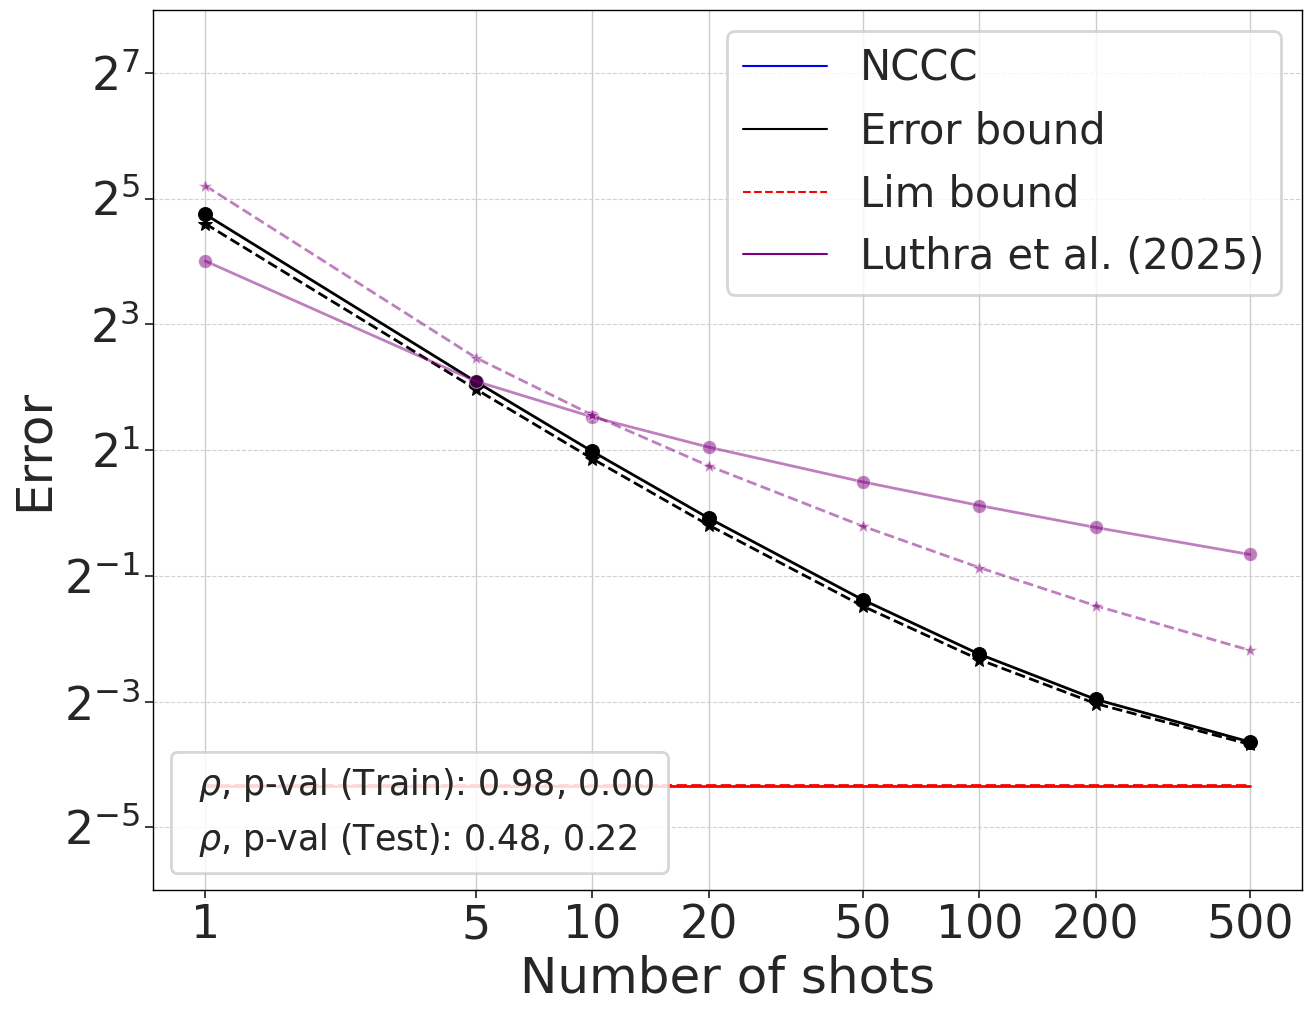

In [13]:
from bound_analysis.bound_viz import plot_error_bound, plot_error_bound_log2
train_error =  1 - nccc_df["train_mean"].values
test_error  =  1 - nccc_df["test_mean"].values
m_values    =  nccc_df["n_shot"].values

plot_error_bound_log2(train_error=train_error,
                 test_error=test_error,
                 m_values=m_values,
                 train_error_bound=final_train_bounds,
                 test_error_bound=final_test_bounds,
                 old_train_error_bound=old_train_error_bounds,
                 old_test_error_bound=old_test_error_bounds,
                 output_path=f"../results/{cur_algo}/error_bounds.png")